<a href="https://colab.research.google.com/github/zakirangwala/esrb-wizard/blob/main/notebooks/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Do Players Prefer Games with Mature Content?**

Regression: can we predict how many minutes a game will have been played in the past two weeks

# Loading Dataset

In [96]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import sklearn
import ast

In [97]:
#loading the dataset (originally from https://www.kaggle.com/datasets/fronkongames/steam-games-dataset; had to manually add a comma to separate Discount and DLC)
from google.colab import drive
drive.mount('/content/drive')

#load data
reg_df = pd.read_csv("/content/drive/MyDrive/CP322/regression.csv") # save to github: notebooks/regression.ipynb

print(reg_df.shape)
reg_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(2739, 122)


,Peak CCU,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Achievements,...,sexual_content,sexual_themes,simulated_gambling,strong_janguage,strong_sexual_content,suggestive_themes,use_of_alcohol,use_of_drugs_and_alcohol,violence,esrb_available
0,2164,59.99,0,5,1,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
1,7571,59.99,0,15,1,0,0,0,0,178,...,0,0,0,0,0,0,0,0,0,0
2,49,3.49,0,0,1,0,0,89,0,0,...,0,0,0,0,0,0,0,0,0,0
3,133,2.99,0,1,1,1,1,0,0,35,...,0,0,0,0,0,0,0,0,0,0
4,358,23.99,0,11,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [98]:
#define target and features
TARGET_COL = "Average playtime two weeks"

#columns that leak "Average playtime two weeks"

leak_cols = [
    "played_before",
    "Publishers",
]

cols_to_drop = [TARGET_COL] + [c for c in leak_cols if c in reg_df.columns]

#drop rows where average playtime does not allow for 8 hours of sleep a night
#deal with outliers and new games possibly
#reg_df.drop(reg_df[reg_df["Average playtime two weeks"] > 15120].index, inplace=True)

#drop target, IDs, and leakage columns
X = reg_df.drop(columns=cols_to_drop, errors="ignore")
y = reg_df[TARGET_COL].astype(int)
reg_df = reg_df.drop(columns=[c for c in leak_cols if c in reg_df.columns], errors="ignore")

#keep only numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns
X = X[numeric_cols]

print("Final feature columns:", list(numeric_cols))
print("X shape:", X.shape)
print("y value counts:")
print(y.value_counts())

reg_df.head()

y_min = y.min()
y_max = y.max()

y_min_log = np.log1p(y).min()
y_max_log = np.log1p(y).max()

Final feature columns: ['Peak CCU', 'Price', 'Discount', 'DLC count', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'User score', 'Achievements', 'Recommendations', 'release_year', 'midpoint_estimated_owners', 'esrb_age', 'voice_acting', '%_positive_reviews', '360 Video', 'Accounting', 'Action', 'Adventure', 'Animation & Modeling', 'Audio Production', 'Casual', 'Design & Illustration', 'Documentary', 'Early Access', 'Education', 'Episodic', 'Game Development', 'Indie', 'Massively Multiplayer', 'Movie', 'Photo Editing', 'RPG', 'Racing', 'Short', 'Simulation', 'Software Training', 'Sports', 'Strategy', 'Tutorial', 'Utilities', 'Video Production', 'Web Publishing', 'Captions available', 'Co-op', 'Commentary available', 'Cross-Platform Multiplayer', 'Family Sharing', 'Full controller support', 'HDR available', 'In-App Purchases', 'Includes Source SDK', 'Includes level editor', 'LAN Co-op', 'LAN PvP', 'MMO', 'Mods', 'Mods (require HL2)', 'Multi-player', 'Online Co-op', 'Online PvP', 'Parti


Distribution of Average playtime two weeks:
count     2739.000000
mean       369.035049
std        923.907960
min          1.000000
25%         27.000000
50%        104.000000
75%        378.000000
max      10996.000000
Name: Average playtime two weeks, dtype: float64


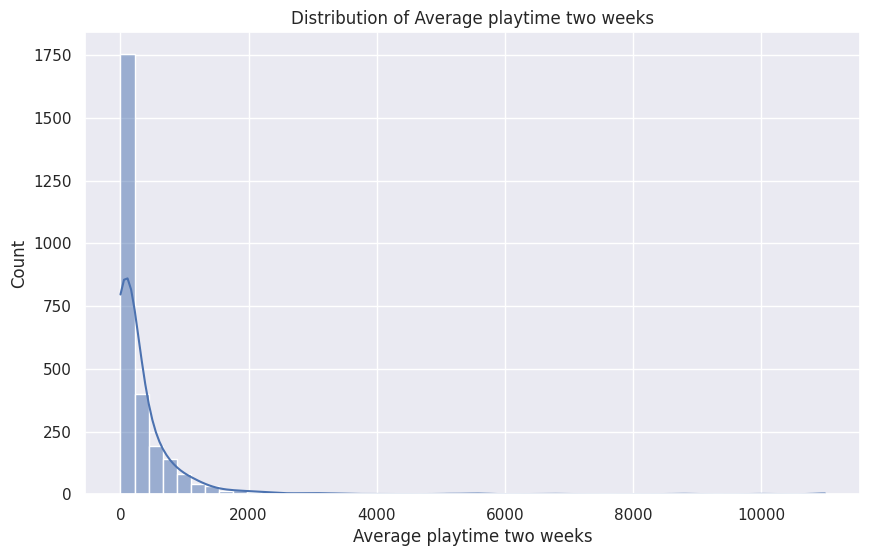

In [99]:
print(f"\nDistribution of {TARGET_COL}:")
print(reg_df[TARGET_COL].describe())
plt.figure(figsize=(10, 6))
sns.histplot(reg_df[TARGET_COL], bins=50, kde=True)
plt.title(f'Distribution of {TARGET_COL}')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()


Distribution of np.log1p(Average playtime two weeks):


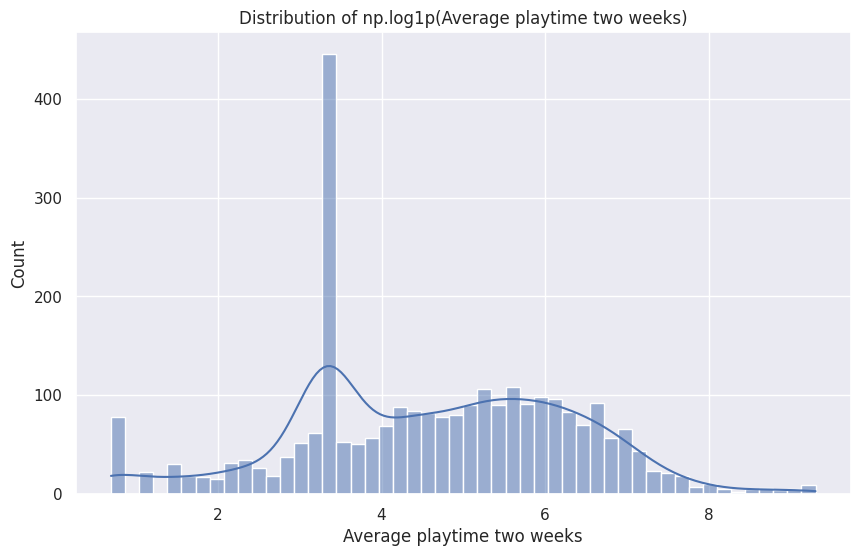

In [100]:
print(f"\nDistribution of np.log1p({TARGET_COL}):")
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(reg_df[TARGET_COL]), bins=50, kde=True)
plt.title(f'Distribution of np.log1p({TARGET_COL})')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()

# Splitting Data into Train/Test/Split

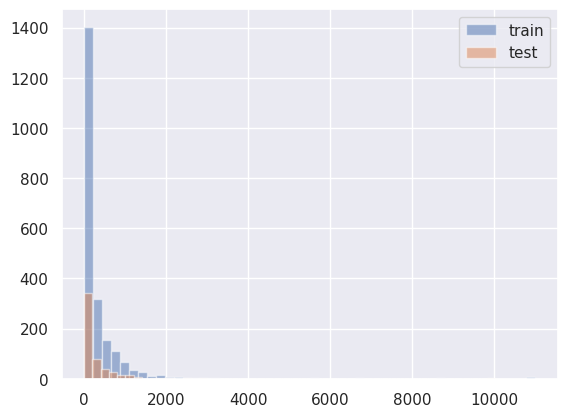

In [101]:
from sklearn.model_selection import train_test_split

# Create quantile bins (e.g., deciles)
reg_df["target_bin"] = pd.qcut(y, q=10, labels=False, duplicates="drop")

# train vs test
train_df, test_df = train_test_split(
    reg_df, test_size=0.2, stratify=reg_df["target_bin"], random_state=42
)

# Drop helper column
for d in [train_df, test_df]:
    d.drop(columns=["target_bin"], inplace=True)


plt.hist(train_df[TARGET_COL], bins=50, alpha=0.5, label='train')
plt.hist(test_df[TARGET_COL], bins=50, alpha=0.5, label='test')
plt.legend()
plt.show()

X_train = train_df.drop(columns=TARGET_COL)
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=TARGET_COL)
y_test = test_df[TARGET_COL]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

By training on log1p(y) skew is reduced so that the model treats large and small playtimes more evenly and feature importance reflects factors affecting typical behavior rather than extreme outliers

# Importing Performance Metrics

In [102]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    average_precision_score,
    precision_recall_curve,
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

# Dataframe to compare performance metrics on classifier models
regression_performance_data = {'Metric': ['MSE',
                                          'RMSE',
                                          'R2',
                                          'MAE']}

reg_performance = pd.DataFrame(regression_performance_data)
reg_performance = reg_performance.set_index('Metric')

print("log1p min: ", np.log1p(reg_df[TARGET_COL]).min())
print("log1p max: ", np.log1p(reg_df[TARGET_COL]).max())

log1p min:  0.6931471805599453
log1p max:  9.305377787310935


#XGBoost

## Basic (No transformation)

In [103]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict

# check model fit based on cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.6, 0.9)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.8)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=50) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

[I 2025-11-24 06:31:30,682] A new study created in memory with name: no-name-d51f4b28-c676-46fc-ad81-71f23b4a1da7
[I 2025-11-24 06:31:31,336] Trial 0 finished with value: -875803.5416666666 and parameters: {'eval_metric': 'rmse', 'n_estimators': 128, 'max_depth': 5, 'min_child_weight': 4, 'gamma': 4.917030675430841, 'max_delta_step': 5, 'learning_rate': 0.08065090084346757, 'subsample': 0.6314506156026689, 'colsample_bytree': 0.5222404179622839, 'reg_alpha': 0.4089479963069681, 'reg_lambda': 5.461534106347056}. Best is trial 0 with value: -875803.5416666666.
[I 2025-11-24 06:31:32,040] Trial 1 finished with value: -872947.9166666666 and parameters: {'eval_metric': 'rmsle', 'n_estimators': 102, 'max_depth': 7, 'min_child_weight': 4, 'gamma': 1.2775081352291717, 'max_delta_step': 7, 'learning_rate': 0.09617754707206641, 'subsample': 0.6052322880464358, 'colsample_bytree': 0.6227475287029348, 'reg_alpha': 2.471498222402314, 'reg_lambda': 1.2156503644967287}. Best is trial 1 with value: -8

Best hyperparameters: {'eval_metric': 'mae', 'n_estimators': 95, 'max_depth': 7, 'min_child_weight': 9, 'gamma': 2.766891618436128, 'max_delta_step': 0, 'learning_rate': 0.014604505158273213, 'subsample': 0.830737206221052, 'colsample_bytree': 0.6287920853231577, 'reg_alpha': 4.509524373547772, 'reg_lambda': 1.1526816015720969}
Best negative MSE: -835372.7708333334


In [104]:
# refit model based on best parameters
regr_xgb = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb,
    X_train,
    y_train,
    cv=kf
)

regr_xgb.fit(X_train, y_train)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Store performance for comparison later
reg_performance['XGBoost'] = [
    mean_squared_error(y_test, y_test_pred),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),
    r2_score(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb = y_test_pred


TRAIN METRICS:
MSE: 835409.75
RMSE: 914.0075218508872
R2: 0.05820959806442261
MAE: 366.1021728515625

TEST METRICS:
MSE: 693791.1875
RMSE: 832.941286946445
R2: 0.03405654430389404
MAE: 352.0321044921875


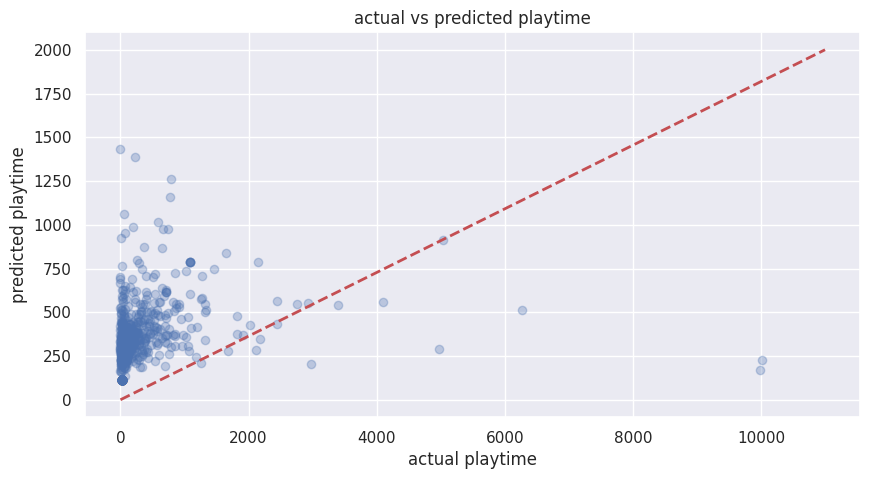

In [105]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [0, 2000], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

## Basic (log1p)

In [108]:
from xgboost import XGBRegressor

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.6, 0.9)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.8)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb_log = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb_log, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
reg_xgb_log = optuna.create_study(direction="maximize")
reg_xgb_log.optimize(xgboostObjective, n_trials=50) #increase if have time
best_params_xgb = reg_xgb_log.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", reg_xgb_log.best_value)

[I 2025-11-24 06:32:44,518] A new study created in memory with name: no-name-648033d3-69f5-4538-a385-c4171a4cb7e1
[I 2025-11-24 06:32:45,125] Trial 0 finished with value: -1.9366684280966047 and parameters: {'eval_metric': 'rmse', 'n_estimators': 91, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 4.293152721454545, 'max_delta_step': 4, 'learning_rate': 0.05700963192368422, 'subsample': 0.6596641788250804, 'colsample_bytree': 0.6615834380426704, 'reg_alpha': 4.682375346103665, 'reg_lambda': 8.968954384139124}. Best is trial 0 with value: -1.9366684280966047.
[I 2025-11-24 06:32:45,800] Trial 1 finished with value: -2.0239934652360985 and parameters: {'eval_metric': 'rmse', 'n_estimators': 105, 'max_depth': 6, 'min_child_weight': 8, 'gamma': 4.730220856555667, 'max_delta_step': 8, 'learning_rate': 0.014932306346186766, 'subsample': 0.8522181954445001, 'colsample_bytree': 0.6476338684061587, 'reg_alpha': 3.4337269029510593, 'reg_lambda': 7.4000685461910685}. Best is trial 0 with value: -

Best hyperparameters: {'eval_metric': 'rmsle', 'n_estimators': 174, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 4.372585264954904, 'max_delta_step': 5, 'learning_rate': 0.034094450757544824, 'subsample': 0.7116014650949393, 'colsample_bytree': 0.5402684911816269, 'reg_alpha': 3.0974897256684373, 'reg_lambda': 0.7830724469593031}
Best negative MSE: -1.902702276838104


Best hyperparameters: {'eval_metric': 'mae', 'n_estimators': 193, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 0.5172732288258364, 'max_delta_step': 0, 'learning_rate': 0.027560536513400923, 'subsample': 0.8923697535139294, 'colsample_bytree': 0.7595714852395946, 'reg_alpha': 1.5018208197138516, 'reg_lambda': 9.292609920015266}
Best negative MSE: -1.8791862282227032

In [109]:
# refit model based on best parameters
regr_xgb_log = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb_log,
    X_train,
    y_train_log,
    cv=kf
)

regr_xgb_log.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb_log.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['XGB (log1p)'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb_log = y_test_pred


TRAIN METRICS:
MSE: 1.9026759061723273
RMSE: 1.3793751868771336
R2: 0.3400127400062354
MAE: 0.9644930863767394

TEST METRICS:
MSE: 2.036840941981096
RMSE: 1.4271793657354692
R2: 0.2914952705731718
MAE: 0.9926906651890839


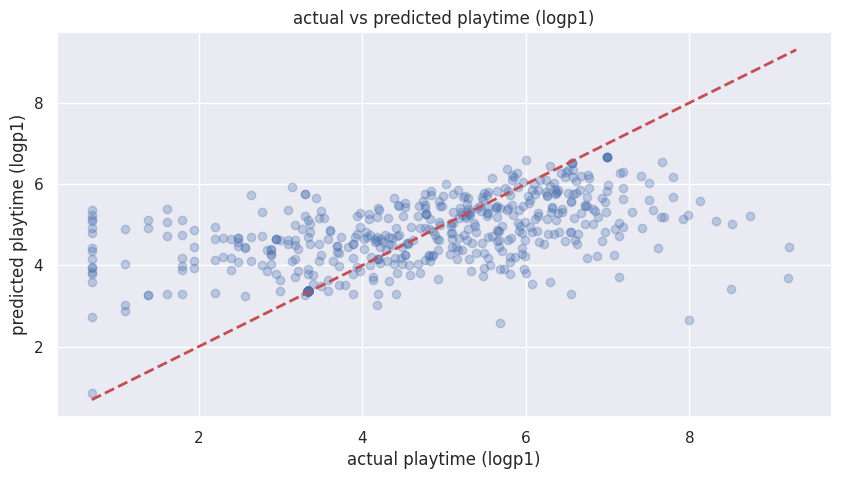

In [110]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_test_pred, alpha=0.3)
plt.plot([np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()],
         [np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()], 'r--', lw=2)
plt.xlabel("actual playtime (logp1)")
plt.ylabel("predicted playtime (logp1)")
plt.title("actual vs predicted playtime (logp1)")
plt.show()

# LightGBM

## Basic (no transformation)

In [111]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

def lightGBMObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 25, 200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    num_leaves = trial.suggest_int("num_leaves", 5, 45)
    max_depth = trial.suggest_int("max_depth", 1, 15)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)
    bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 0.8)
    feature_fraction = trial.suggest_float("feature_fraction", 0.6, 0.9)

    # lightgbm regression
    regr = LGBMRegressor(
        boosting_type="gbdt",
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_depth=max_depth,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        bagging_fraction=bagging_fraction,
        feature_fraction=feature_fraction,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # precision is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(regr, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_light = optuna.create_study(direction="minimize")
study_light.optimize(lightGBMObjective, n_trials=50) #increase if have time
best_params_light = study_light.best_params

# print best parameters
print("Best hyperparameters:", best_params_light)
print("Best average precision:", study_light.best_value)

[I 2025-11-24 06:33:39,804] A new study created in memory with name: no-name-313a466b-b745-4b08-a637-04d6ed87015a
[I 2025-11-24 06:33:40,055] Trial 0 finished with value: -839579.3621599451 and parameters: {'n_estimators': 180, 'learning_rate': 0.01016639868721513, 'num_leaves': 5, 'max_depth': 10, 'min_child_samples': 78, 'reg_alpha': 0.4067404257673781, 'reg_lambda': 7.3293932818853875, 'bagging_fraction': 0.742716799482714, 'feature_fraction': 0.8347475160926344}. Best is trial 0 with value: -839579.3621599451.
[I 2025-11-24 06:33:40,166] Trial 1 finished with value: -843953.7153525843 and parameters: {'n_estimators': 29, 'learning_rate': 0.051983203731625995, 'num_leaves': 35, 'max_depth': 15, 'min_child_samples': 96, 'reg_alpha': 0.3436903326574139, 'reg_lambda': 2.075379490018218, 'bagging_fraction': 0.7786451884531307, 'feature_fraction': 0.6279044562565597}. Best is trial 1 with value: -843953.7153525843.
[I 2025-11-24 06:33:40,398] Trial 2 finished with value: -842959.70531855

Best hyperparameters: {'n_estimators': 200, 'learning_rate': 0.09417672328164176, 'num_leaves': 28, 'max_depth': 14, 'min_child_samples': 34, 'reg_alpha': 0.7173449282011229, 'reg_lambda': 1.6530892422885142, 'bagging_fraction': 0.6385067914140826, 'feature_fraction': 0.6386395183520833}
Best average precision: -937877.4492444122


In [112]:
# refit model based on best parameters
regr_light = LGBMRegressor(
        boosting_type="gbdt",
        **best_params_light,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_light,
    X_train,
    y_train,
    cv=kf
)

regr_light.fit(X_train, y_train)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Evaluate test data
y_test_pred = regr_light.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Store performance for comparison later
reg_performance['LightGBM'] = [
    mean_squared_error(y_test, y_test_pred),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),
    r2_score(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred)
]

# to draw PR_AUC later on
y_test_pred_light = y_test_pred


TRAIN METRICS:
MSE: 937924.8879106094
RMSE: 968.4652228710174
R2: -0.05735977305464557
MAE: 431.80138342117027

TEST METRICS:
MSE: 792216.1517821522
RMSE: 890.0652514182049
R2: -0.10297740958115797
MAE: 395.0335787159767


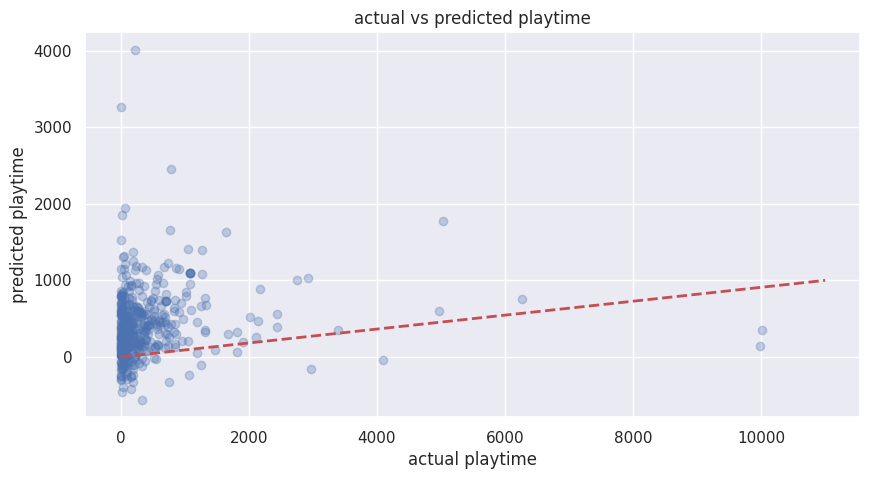

In [113]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y.min(), y.max()],
         [0, 1000], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

## Basic (log1p)

In [114]:
def lightGBMObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 25, 200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    num_leaves = trial.suggest_int("num_leaves", 5, 45)
    max_depth = trial.suggest_int("max_depth", 1, 15)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)
    bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 0.8)
    feature_fraction = trial.suggest_float("feature_fraction", 0.6, 0.9)

    # lightgbm regression
    regr = LGBMRegressor(
        boosting_type="gbdt",
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_depth=max_depth,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        bagging_fraction=bagging_fraction,
        feature_fraction=feature_fraction,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # precision is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(regr, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_light = optuna.create_study(direction="minimize")
study_light.optimize(lightGBMObjective, n_trials=50) #increase if have time
best_params_light = study_light.best_params

# print best parameters
print("Best hyperparameters:", best_params_light)
print("Best average precision:", study_light.best_value)

[I 2025-11-24 06:34:01,708] A new study created in memory with name: no-name-3391f13f-cd72-4bd0-99e3-6b3490e8dbdd
[I 2025-11-24 06:34:01,888] Trial 0 finished with value: -2.0436613163890205 and parameters: {'n_estimators': 53, 'learning_rate': 0.03203935717017023, 'num_leaves': 30, 'max_depth': 13, 'min_child_samples': 100, 'reg_alpha': 0.4895240857338162, 'reg_lambda': 7.3168394045861165, 'bagging_fraction': 0.6867105498277933, 'feature_fraction': 0.8494637443523587}. Best is trial 0 with value: -2.0436613163890205.
[I 2025-11-24 06:34:02,305] Trial 1 finished with value: -1.972417147218069 and parameters: {'n_estimators': 180, 'learning_rate': 0.07104077320808168, 'num_leaves': 39, 'max_depth': 2, 'min_child_samples': 37, 'reg_alpha': 0.8504526878059504, 'reg_lambda': 9.592906063178667, 'bagging_fraction': 0.6335594297154563, 'feature_fraction': 0.6740305740127276}. Best is trial 0 with value: -2.0436613163890205.
[I 2025-11-24 06:34:03,132] Trial 2 finished with value: -2.021239813

Best hyperparameters: {'n_estimators': 116, 'learning_rate': 0.010796828186302636, 'num_leaves': 37, 'max_depth': 1, 'min_child_samples': 178, 'reg_alpha': 0.11589315709756562, 'reg_lambda': 3.47964258652366, 'bagging_fraction': 0.6791475413154521, 'feature_fraction': 0.8748951605830465}
Best average precision: -2.345262196382652


In [115]:
# refit model based on best parameters
regr_light_log = LGBMRegressor(
        boosting_type="gbdt",
        **best_params_light,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_light_log,
    X_train,
    y_train_log,
    cv=kf
)

regr_light_log.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_light_log.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['LGBM (log1p)'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# to draw PR_AUC later on
y_test_pred_light_log = y_test_pred


TRAIN METRICS:
MSE: 2.3452087504417913
RMSE: 1.5314074410299146
R2: 0.18650996089436378
MAE: 1.2075746630094166

TEST METRICS:
MSE: 2.3195903354850085
RMSE: 1.5230201362703675
R2: 0.19314233666894542
MAE: 1.2080812528941618


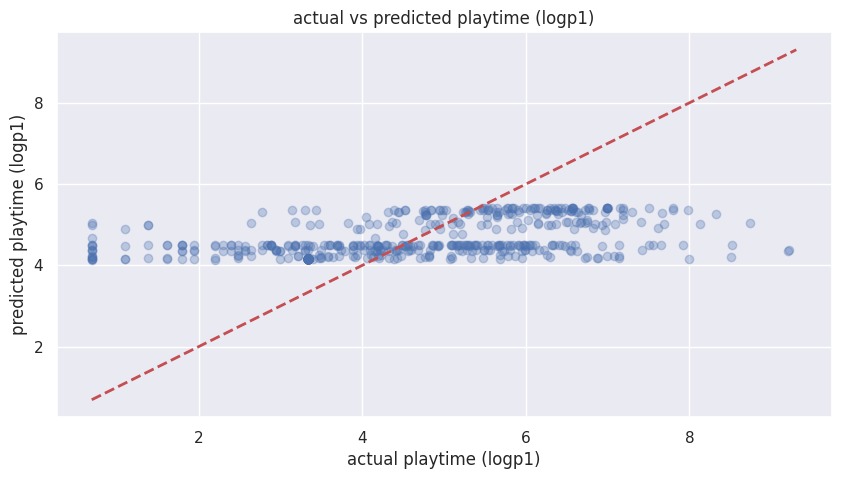

In [116]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_test_pred, alpha=0.3)
plt.plot([np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()],
         [np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()], 'r--', lw=2)
plt.xlabel("actual playtime (logp1)")
plt.ylabel("predicted playtime (logp1)")
plt.title("actual vs predicted playtime (logp1)")
plt.show()

# Removing outliers of response variable

In [117]:
# Computing IQR
Q1 = np.percentile(reg_df[TARGET_COL], 25)
Q3 = np.percentile(reg_df[TARGET_COL], 75)
IQR = Q3 - Q1
IQR

# Defining the bounds for the Price feature
lower = Q1 - 3*IQR
upper = Q3 + 3*IQR

# Removing any rows where price is outside the bounds
reg_df = reg_df[(reg_df[TARGET_COL] >= lower) & (reg_df[TARGET_COL] <= upper)]

X = reg_df.drop(columns=TARGET_COL, errors="ignore")
y = reg_df[TARGET_COL].astype(int)

y_min_iqr = y.min()
y_max_iqr = y.max()

y_min_IQR_log = np.log1p(y).min()
y_max_IQR_log = np.log1p(y).max()


Distribution of Average playtime two weeks:
count    2625.000000
mean      228.811810
std       296.976699
min         1.000000
25%        27.000000
50%        91.000000
75%       322.000000
max      1430.000000
Name: Average playtime two weeks, dtype: float64


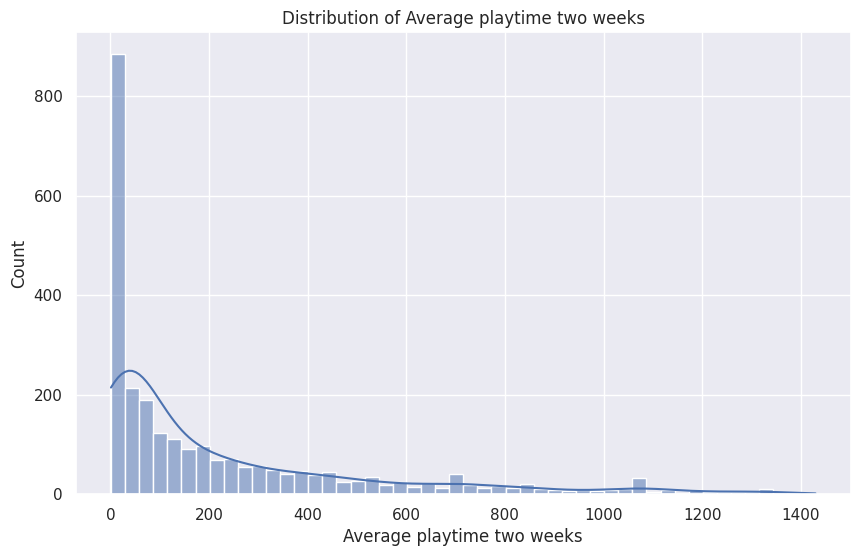

In [118]:
print(f"\nDistribution of {TARGET_COL}:")
print(reg_df[TARGET_COL].describe())
plt.figure(figsize=(10, 6))
sns.histplot(reg_df[TARGET_COL], bins=50, kde=True)
plt.title(f'Distribution of {TARGET_COL}')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()


Distribution of np.log1p(Average playtime two weeks):


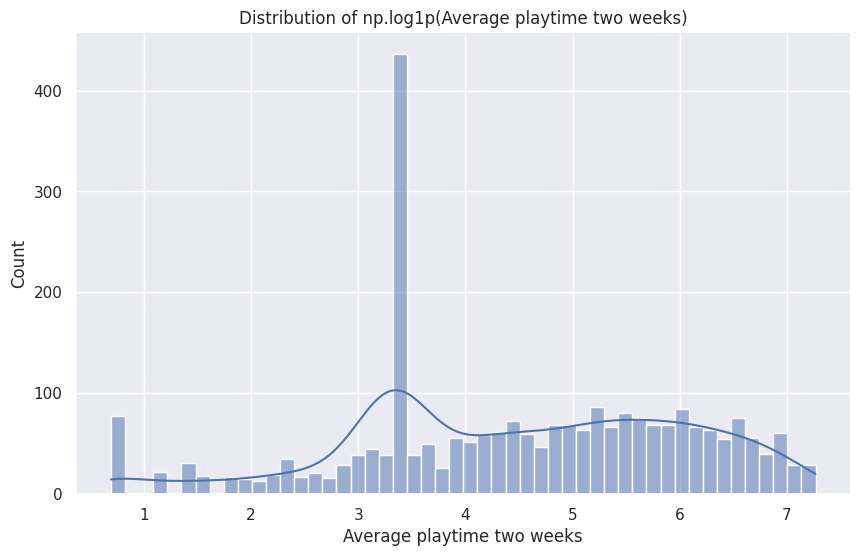

In [119]:
print(f"\nDistribution of np.log1p({TARGET_COL}):")
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(reg_df[TARGET_COL]), bins=50, kde=True)
plt.title(f'Distribution of np.log1p({TARGET_COL})')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()

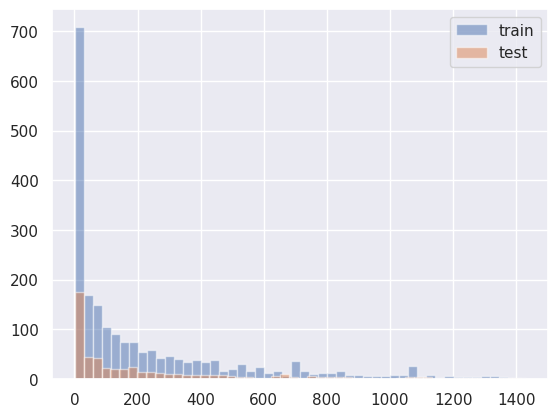

In [120]:
from sklearn.model_selection import train_test_split

# Create quantile bins (e.g., deciles)
reg_df["target_bin"] = pd.qcut(y, q=10, labels=False, duplicates="drop")

# train vs test
train_df, test_df = train_test_split(
    reg_df, test_size=0.2, stratify=reg_df["target_bin"], random_state=42
)

# Drop helper column
for d in [train_df, test_df]:
    d.drop(columns=["target_bin"], inplace=True)


plt.hist(train_df[TARGET_COL], bins=50, alpha=0.5, label='train')
plt.hist(test_df[TARGET_COL], bins=50, alpha=0.5, label='test')
plt.legend()
plt.show()

X_train = train_df.drop(columns=TARGET_COL)
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=TARGET_COL)
y_test = test_df[TARGET_COL]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# XGBoost (IQR)

## Basic (No transformation)

In [121]:
# check model fit based on cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.6, 0.9)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.8)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=50) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

[I 2025-11-24 06:34:14,111] A new study created in memory with name: no-name-47d0b7e6-9c36-456e-9e71-9c30798e848d
[I 2025-11-24 06:34:14,829] Trial 0 finished with value: -68545.09635416667 and parameters: {'eval_metric': 'mae', 'n_estimators': 199, 'max_depth': 3, 'min_child_weight': 3, 'gamma': 2.685376878793557, 'max_delta_step': 8, 'learning_rate': 0.09362033079297206, 'subsample': 0.8631395773610263, 'colsample_bytree': 0.6690815708827001, 'reg_alpha': 1.8174843007451735, 'reg_lambda': 5.825577881507953}. Best is trial 0 with value: -68545.09635416667.
[I 2025-11-24 06:34:15,395] Trial 1 finished with value: -84969.27083333333 and parameters: {'eval_metric': 'rmsle', 'n_estimators': 94, 'max_depth': 6, 'min_child_weight': 9, 'gamma': 1.9067801421447927, 'max_delta_step': 1, 'learning_rate': 0.08569430183256864, 'subsample': 0.8918338044404683, 'colsample_bytree': 0.6260818955687694, 'reg_alpha': 2.389950953549642, 'reg_lambda': 8.073328579766455}. Best is trial 0 with value: -6854

Best hyperparameters: {'eval_metric': 'rmse', 'n_estimators': 73, 'max_depth': 6, 'min_child_weight': 2, 'gamma': 2.886436177175908, 'max_delta_step': 0, 'learning_rate': 0.04140034486677194, 'subsample': 0.7684337992322373, 'colsample_bytree': 0.6027982731441495, 'reg_alpha': 4.971307895813177, 'reg_lambda': 9.995724337315135}
Best negative MSE: -60227.078125


In [122]:
# refit model based on best parameters
regr_xgb_iqr = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb_iqr,
    X_train,
    y_train,
    cv=kf
)

regr_xgb_iqr.fit(X_train, y_train)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb_iqr.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Store performance for comparison later
reg_performance['XGB IQR'] = [
    mean_squared_error(y_test, y_test_pred),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),
    r2_score(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb_iqr = y_test_pred


TRAIN METRICS:
MSE: 60227.078125
RMSE: 245.41205782316402
R2: 0.30312854051589966
MAE: 161.36349487304688

TEST METRICS:
MSE: 64603.6640625
RMSE: 254.1725084711169
R2: 0.32046544551849365
MAE: 163.40223693847656


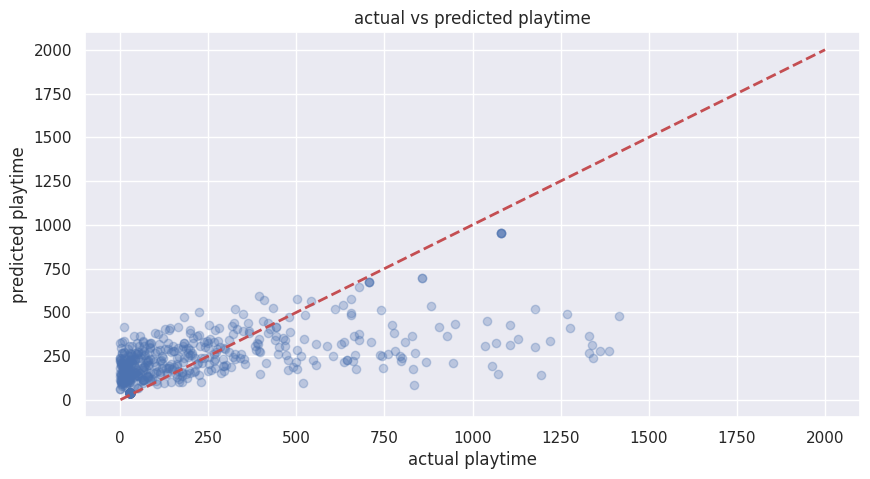

In [123]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y.min(), 2000], [0, 2000], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

## Basic (log1p)

In [124]:
def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.6, 0.9)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.8)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=50) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

[I 2025-11-24 06:35:00,678] A new study created in memory with name: no-name-e8bd2873-1fb1-4794-a8d5-04012f079375
[I 2025-11-24 06:35:01,231] Trial 0 finished with value: -1.6280433892140758 and parameters: {'eval_metric': 'rmse', 'n_estimators': 105, 'max_depth': 4, 'min_child_weight': 9, 'gamma': 0.6660803660605935, 'max_delta_step': 10, 'learning_rate': 0.04412796810630253, 'subsample': 0.7911041210043124, 'colsample_bytree': 0.6855197437491132, 'reg_alpha': 1.250034191863515, 'reg_lambda': 1.4199284441539195}. Best is trial 0 with value: -1.6280433892140758.
[I 2025-11-24 06:35:01,866] Trial 1 finished with value: -1.8766673621776782 and parameters: {'eval_metric': 'rmse', 'n_estimators': 77, 'max_depth': 7, 'min_child_weight': 7, 'gamma': 2.2509212115716655, 'max_delta_step': 4, 'learning_rate': 0.010778888921913799, 'subsample': 0.8904915239196786, 'colsample_bytree': 0.5642723220231294, 'reg_alpha': 2.684080377448085, 'reg_lambda': 5.032997216902187}. Best is trial 0 with value:

Best hyperparameters: {'eval_metric': 'rmse', 'n_estimators': 173, 'max_depth': 5, 'min_child_weight': 9, 'gamma': 0.19145774124073034, 'max_delta_step': 4, 'learning_rate': 0.02835327555370658, 'subsample': 0.8469571758117871, 'colsample_bytree': 0.7329071925849963, 'reg_alpha': 1.1889293970170156, 'reg_lambda': 7.2173906612812}
Best negative MSE: -1.6145167839357875


In [125]:
# refit model based on best parameters
regr_xgb_iqr_log = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb_iqr_log,
    X_train,
    y_train_log,
    cv=kf
)

regr_xgb_iqr_log.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb_iqr_log.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['XGB IQR (log)'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb_iqr_log = y_test_pred


TRAIN METRICS:
MSE: 1.6145167839357872
RMSE: 1.2706363696730025
R2: 0.35079903668806045
MAE: 0.8974265279596078

TEST METRICS:
MSE: 1.4025920514294838
RMSE: 1.1843107917390112
R2: 0.4304732355453178
MAE: 0.8460630995155931


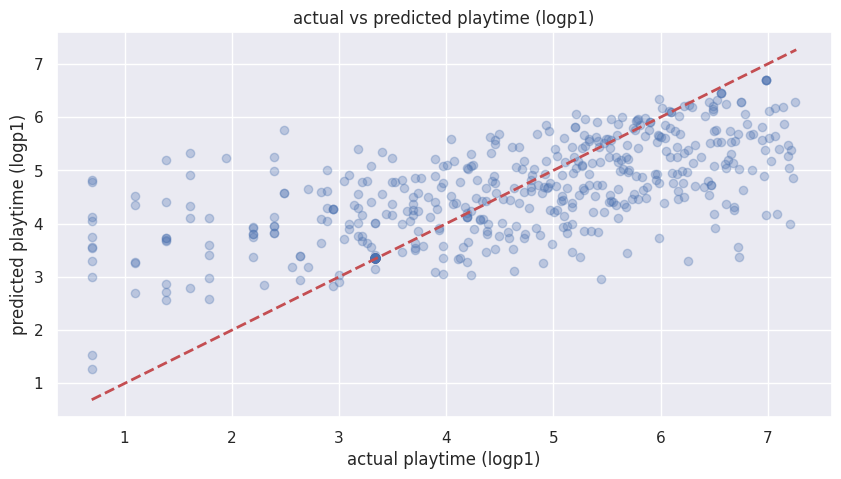

In [126]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_test_pred, alpha=0.3)
plt.plot([np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()],
         [np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()], 'r--', lw=2)
plt.xlabel("actual playtime (logp1)")
plt.ylabel("predicted playtime (logp1)")
plt.title("actual vs predicted playtime (logp1)")
plt.show()

# LightGBM (IQR)

## Basic (No transformation)

In [127]:
def lightGBMObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 25, 200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    num_leaves = trial.suggest_int("num_leaves", 5, 45)
    max_depth = trial.suggest_int("max_depth", 1, 15)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)
    bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 0.8)
    feature_fraction = trial.suggest_float("feature_fraction", 0.6, 0.9)

    # lightgbm regression
    regr = LGBMRegressor(
        boosting_type="gbdt",
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_depth=max_depth,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        bagging_fraction=bagging_fraction,
        feature_fraction=feature_fraction,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # precision is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(regr, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_light = optuna.create_study(direction="minimize")
study_light.optimize(lightGBMObjective, n_trials=50) #increase if have time
best_params_light = study_light.best_params

# print best parameters
print("Best hyperparameters:", best_params_light)
print("Best average precision:", study_light.best_value)

[I 2025-11-24 06:35:44,770] A new study created in memory with name: no-name-d24d7f60-7f38-490e-beeb-55596870ac23
[I 2025-11-24 06:35:44,874] Trial 0 finished with value: -64212.00643040296 and parameters: {'n_estimators': 68, 'learning_rate': 0.05578555001173032, 'num_leaves': 13, 'max_depth': 2, 'min_child_samples': 151, 'reg_alpha': 0.8484961245177289, 'reg_lambda': 2.7059698481888095, 'bagging_fraction': 0.719203894080957, 'feature_fraction': 0.7799010023469605}. Best is trial 0 with value: -64212.00643040296.
[I 2025-11-24 06:35:45,336] Trial 1 finished with value: -62771.2166772862 and parameters: {'n_estimators': 131, 'learning_rate': 0.06985811330054202, 'num_leaves': 36, 'max_depth': 12, 'min_child_samples': 27, 'reg_alpha': 0.886245227678338, 'reg_lambda': 4.587367520809015, 'bagging_fraction': 0.6806085986828718, 'feature_fraction': 0.6584439177294448}. Best is trial 0 with value: -64212.00643040296.
[I 2025-11-24 06:35:45,471] Trial 2 finished with value: -65221.76044497624

Best hyperparameters: {'n_estimators': 38, 'learning_rate': 0.01003635819156099, 'num_leaves': 37, 'max_depth': 11, 'min_child_samples': 166, 'reg_alpha': 0.05935028897706334, 'reg_lambda': 6.548437797030219, 'bagging_fraction': 0.684992903978111, 'feature_fraction': 0.7207021421800496}
Best average precision: -76614.29252418513


In [128]:
# refit model based on best parameters
regr_light_iqr = LGBMRegressor(
        boosting_type="gbdt",
        **best_params_light,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_light_iqr,
    X_train,
    y_train,
    cv=kf
)

regr_light_iqr.fit(X_train, y_train)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Evaluate test data
y_test_pred = regr_light_iqr.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Store performance for comparison later
reg_performance['LGBM IQR'] = [
    mean_squared_error(y_test, y_test_pred),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),
    r2_score(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred)
]

# to draw PR_AUC later on
y_test_pred_iqr_light = y_test_pred


TRAIN METRICS:
MSE: 76614.29252418512
RMSE: 276.7928693521297
R2: 0.11351638191079427
MAE: 205.07600914185227

TEST METRICS:
MSE: 82506.88631641703
RMSE: 287.24011961496086
R2: 0.13215019536910844
MAE: 207.67053031643403


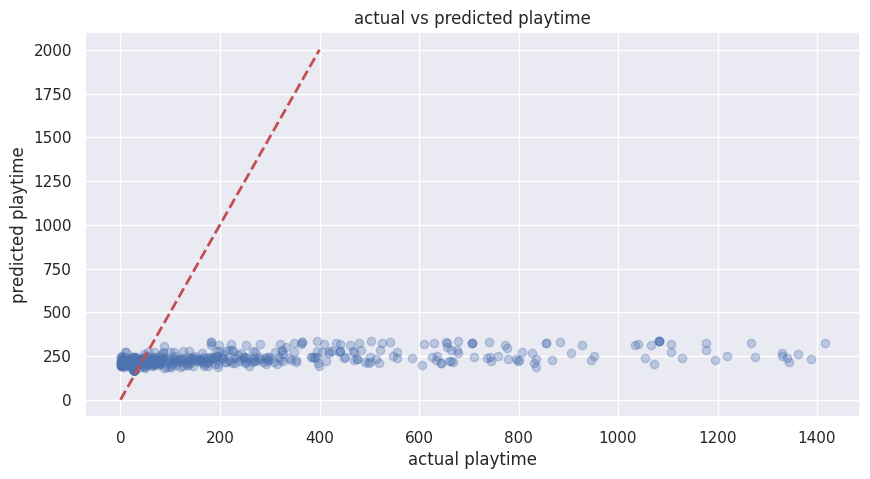

In [129]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([0, 400],
         [0, 2000], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

## Basic (log1p)

In [130]:
def lightGBMObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 25, 200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    num_leaves = trial.suggest_int("num_leaves", 5, 45)
    max_depth = trial.suggest_int("max_depth", 1, 15)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)
    bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 0.8)
    feature_fraction = trial.suggest_float("feature_fraction", 0.6, 0.9)

    # lightgbm regression
    regr = LGBMRegressor(
        boosting_type="gbdt",
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_depth=max_depth,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        bagging_fraction=bagging_fraction,
        feature_fraction=feature_fraction,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # precision is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(regr, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_light = optuna.create_study(direction="minimize")
study_light.optimize(lightGBMObjective, n_trials=50) #increase if have time
best_params_light = study_light.best_params

# print best parameters
print("Best hyperparameters:", best_params_light)
print("Best average precision:", study_light.best_value)

[I 2025-11-24 06:35:55,840] A new study created in memory with name: no-name-709c16ea-bc7e-4d8c-bfa1-efbe2f33b469
[I 2025-11-24 06:35:55,969] Trial 0 finished with value: -1.6569843482787394 and parameters: {'n_estimators': 38, 'learning_rate': 0.08327582824937863, 'num_leaves': 18, 'max_depth': 11, 'min_child_samples': 98, 'reg_alpha': 0.16739340612656772, 'reg_lambda': 2.235515162580511, 'bagging_fraction': 0.7739043565985609, 'feature_fraction': 0.8782137047394157}. Best is trial 0 with value: -1.6569843482787394.
[I 2025-11-24 06:35:56,287] Trial 1 finished with value: -1.6841267362321688 and parameters: {'n_estimators': 175, 'learning_rate': 0.07952049612291782, 'num_leaves': 12, 'max_depth': 5, 'min_child_samples': 74, 'reg_alpha': 0.9429017075236062, 'reg_lambda': 1.4706662420981897, 'bagging_fraction': 0.7204767132278707, 'feature_fraction': 0.6179068606637028}. Best is trial 1 with value: -1.6841267362321688.
[I 2025-11-24 06:35:56,500] Trial 2 finished with value: -1.65101210

Best hyperparameters: {'n_estimators': 25, 'learning_rate': 0.014819338434771737, 'num_leaves': 32, 'max_depth': 1, 'min_child_samples': 102, 'reg_alpha': 0.9038057316932286, 'reg_lambda': 0.41346938819112733, 'bagging_fraction': 0.7154736751229487, 'feature_fraction': 0.8168194317244241}
Best average precision: -2.2272870218648477


In [131]:
# refit model based on best parameters
regr_light_iqr_log = LGBMRegressor(
        boosting_type="gbdt",
        **best_params_light,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_light_iqr_log,
    X_train,
    y_train_log,
    cv=kf
)

regr_light_iqr_log.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_light_iqr_log.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['LGBM IQR (log)'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# to draw PR_AUC later on
y_test_pred_light_iqr_log = y_test_pred


TRAIN METRICS:
MSE: 2.2272870218648477
RMSE: 1.4924098035944577
R2: 0.10440269524980739
MAE: 1.2336971878698686

TEST METRICS:
MSE: 2.175432141207048
RMSE: 1.4749346226891036
R2: 0.11665916870864212
MAE: 1.2279903234234872


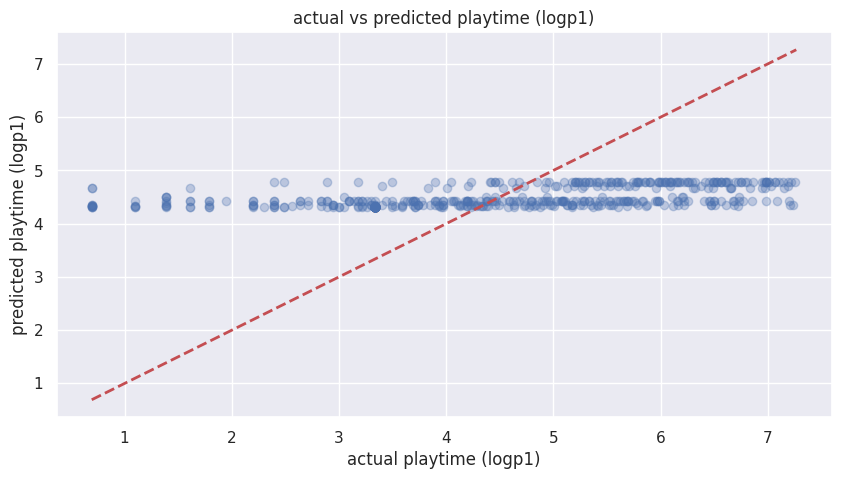

In [132]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_test_pred, alpha=0.3)
plt.plot([np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()],
         [np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()], 'r--', lw=2)
plt.xlabel("actual playtime (logp1)")
plt.ylabel("predicted playtime (logp1)")
plt.title("actual vs predicted playtime (logp1)")
plt.show()

# Performance Measure Comparison

In [133]:
print("y value range: ", y_min, y_max)
print("y value range IQR: ", y_min_iqr, y_max_iqr)
print("y_log value range: ", y_min_log, y_max_log)
print("y_log value range IQR: ", y_min_IQR_log, y_max_IQR_log)
reg_performance.head()

y value range:  1 10996
y value range IQR:  1 1430
y_log value range:  0.6931471805599453 9.305377787310935
y_log value range IQR:  0.6931471805599453 7.266128779556451


,XGBoost,XGB (log1p),LightGBM,LGBM (log1p),XGB IQR,XGB IQR (log),LGBM IQR,LGBM IQR (log)
Metric,,,,,,,,
MSE,693791.187500,2.036841,792216.151782,2.319590,64603.664062,1.402592,82506.886316,2.175432
RMSE,832.941287,1.427179,890.065251,1.523020,254.172508,1.184311,287.240120,1.474935
R2,0.034057,0.291495,-0.102977,0.193142,0.320465,0.430473,0.132150,0.116659
MAE,352.032104,0.992691,395.033579,1.208081,163.402237,0.846063,207.670530,1.227990


In [137]:
#identify important features
#rename models first - forgot to do that
print("important features:")
feature_importances = pd.Series(regr_xgb_iqr_log.feature_importances_, index=X_train.columns)
print(feature_importances.nlargest(40))

important features:
Peak CCU                      0.067744
Remote Play on TV             0.056774
Price                         0.040309
Linux                         0.030310
release_year                  0.025683
RPG                           0.023961
Steam Trading Cards           0.023195
Co-op                         0.022892
Recommendations               0.021729
Strategy                      0.021184
voice_acting                  0.020262
Online Co-op                  0.019912
Indie                         0.019912
midpoint_estimated_owners     0.018208
Massively Multiplayer         0.017885
Full controller support       0.016486
Free to Play                  0.016398
Early Access                  0.016087
MMO                           0.014811
Remote Play on Tablet         0.014575
Steam Achievements            0.014556
Steam Leaderboards            0.014477
Shared/Split Screen PvP       0.014174
Single-player                 0.014042
Casual                        0.013960
Achie

In [138]:
import shap

explainer = shap.TreeExplainer(regr_xgb)
shap_values = explainer(X_test)

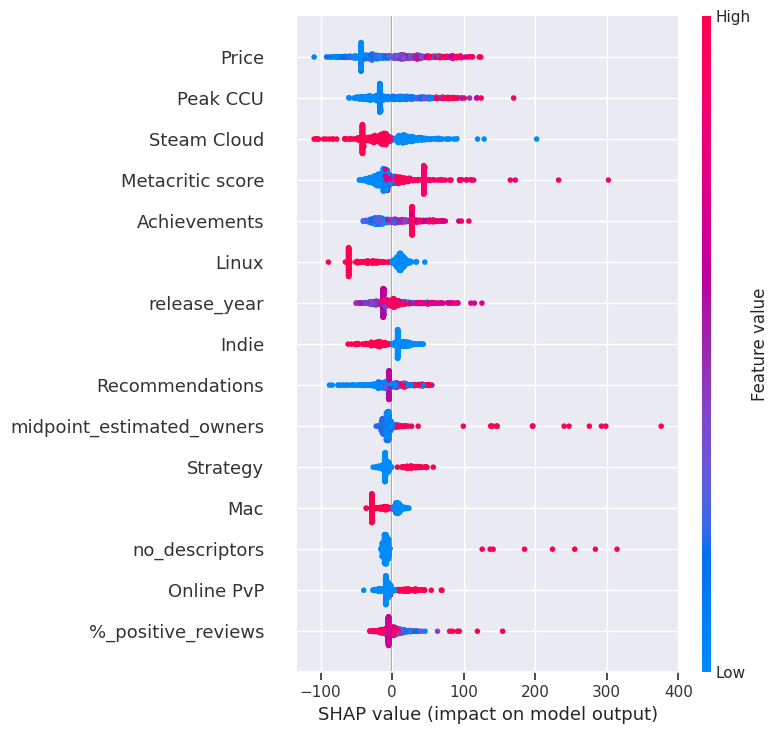

In [139]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

# Ablation

In [ ]:
# drop peak CCU since it makes sense that players would pick popular
X_train = X_train.drop(columns=["Peak CCU"])
X_test = X_test.drop(columns=["Peak CCU"])

In [ ]:
# running xgboost again
from xgboost import XGBRegressor

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    subsample = trial.suggest_float("subsample", 0.1, 1)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=15) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

In [ ]:
# refit model based on best parameters
regr_xgb = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb,
    X_train,
    y_train_log,
    cv=kf
)

regr_xgb.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['Random Forest'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb = y_test_pred

In [ ]:
#identify important features
print("important features:")
feature_importances = pd.Series(regr_xgb.feature_importances_, index=X_train.columns)
print(feature_importances.nlargest(20))